# Этап 1. Исследование данных (EDA)

Цель: понять состав датасета Zingat, качество записей и связь характеристик жилья с ценой. Исходный CSV остаётся без изменений. В разделах с ценой сравниваются только объявления одного типа и одной валюты.

## 1.1. Знакомство с данными

Источник — файл `data/real_estate_data.csv`; пояснения к полям — `data/zingat_data_info.docx`. Это объявления о недвижимости Турции, а не сведения о состоявшихся сделках. Целевая переменная — `price` в валюте `price_currency`. `size` измеряется в м², `tom` — в днях, `building_age` — возраст здания в годах или интервал возраста. `address` содержит город/район/микрорайон.

In [1]:
# Библиотеки и путь к данным: работает из корня проекта и из папки notebooks.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = next((p for p in (Path("data/real_estate_data.csv"), Path("../data/real_estate_data.csv")) if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Не найден data/real_estate_data.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)
original_columns = df.columns.tolist()
print(f"Размер датасета: {df.shape[0]:,} строк и {df.shape[1]} столбцов")
display(pd.DataFrame({"тип": df.dtypes.astype(str), "заполнено": df.notna().sum(), "уникальных": df.nunique(dropna=True)}))

Размер датасета: 403,487 строк и 17 столбцов


,тип,заполнено,уникальных
id,int64,403487,403487
type,object,403487,1
sub_type,object,403487,12
start_date,object,403487,181
end_date,object,266298,181
listing_type,int64,403487,3
tom,int64,403487,181
building_age,object,376097,14
total_floor_count,object,375466,12
floor_no,object,368191,35


In [2]:
# Первые, последние и одна воспроизводимая случайная запись.
print("Первые строки"); display(df.head(5))
print("Последние строки"); display(df.tail(5))
print("Случайная строка"); display(df.sample(1, random_state=RANDOM_STATE))
dates = pd.to_datetime(df.start_date, format="%m/%d/%y", errors="coerce")
print("Период начала публикации:", dates.min().date(), "—", dates.max().date())
print("Валюты:", df.price_currency.value_counts(dropna=False).to_dict())

Первые строки


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


Последние строки


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


Случайная строка


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


Период начала публикации: 2018-08-31 — 2019-02-27
Валюты: {'TRY': 400677, 'EUR': 922, nan: 715, 'GBP': 621, 'USD': 552}


**Вывод 1.1.** В исходном файле 403 487 строк и 17 столбцов; объявления относятся к 2018–2019 годам. `type` везде означает жильё. Встречаются разные валюты и числовые коды `listing_type`, поэтому сравнивать все цены вместе нельзя. Словарь не расшифровывает коды 1/2/3: по медианам код 1 предварительно соответствует продаже, код 2 — аренде. Перед моделированием это следует подтвердить у источника.

## 1.2. Описательная статистика

Сначала считаем статистики всего датасета, затем цены в сопоставимом сегменте. Для числовых полей показываем минимум, максимум, среднее, медиану, стандартное отклонение и квартили. Для категорий — количество уникальных значений и частоты.

In [3]:
# Числовые поля: сводка включает запрошенные квартили и разброс.
numeric_summary = df.select_dtypes(include="number").describe(percentiles=[.25, .5, .75]).T
display(numeric_summary[["count", "min", "25%", "50%", "mean", "75%", "max", "std"]])

,count,min,25%,50%,mean,75%,max,std
id,403487.0,1.0,100872.5,201744.0,201744.000000,302615.5,4.034870e+05,1.164768e+05
listing_type,403487.0,1.0,1.0,1.0,1.294235,2.0,3.000000e+00,4.677333e-01
tom,403487.0,0.0,29.0,40.0,57.022739,90.0,1.800000e+02,4.435893e+01
size,257481.0,1.0,85.0,110.0,279.349094,140.0,9.482350e+05,9.429195e+03
furnished,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,402772.0,-250.0,2500.0,199000.0,354641.661933,342000.0,2.000000e+09,4.809503e+06


In [4]:
# Для каждого категориального поля выводим число категорий и частоты.
categorical_cols = df.select_dtypes(include=["object"]).columns
category_summary = pd.DataFrame({
    "уникальных": df[categorical_cols].nunique(dropna=True),
    "наиболее частое": [df[c].mode(dropna=True).iloc[0] if df[c].notna().any() else None for c in categorical_cols],
    "частота": [df[c].value_counts(dropna=True).iloc[0] if df[c].notna().any() else 0 for c in categorical_cols]
}, index=categorical_cols)
display(category_summary)
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    print(f"{col}: {len(counts)} категорий с учётом пропуска; 10 наиболее частых")
    display(counts.head(10).to_frame("количество"))
# Все частоты доступны без ограничения, например: df["address"].value_counts(dropna=False)

,уникальных,наиболее частое,частота
type,1,Konut,403487
sub_type,12,Daire,354549
start_date,181,10/11/18,4064
end_date,181,12/19/18,3048
building_age,14,0,140174
total_floor_count,12,4,83082
floor_no,35,2,65864
room_count,37,3+1,157363
address,7842,Balıkesir/Edremit/Akçay,5611
heating_type,16,Kombi (Doğalgaz),204150


type: 1 категорий с учётом пропуска; 10 наиболее частых


,количество
type,
Konut,403487


sub_type: 12 категорий с учётом пропуска; 10 наиболее частых


,количество
sub_type,
Daire,354549
Villa,21324
Müstakil Ev,9563
Rezidans,7716
Yazlık,5929
Komple Bina,2607
Prefabrik Ev,679
Çiftlik Evi,528
Köşk / Konak / Yalı,301


...

,количество
address,
Balıkesir/Edremit/Akçay,5611
Aydın/Didim/Efeler,4203
İstanbul/Beylikdüzü/Cumhuriyet,3283
İstanbul/Bahçelievler/Siyavuşpaşa,2139
Aydın/Didim/Altınkum,2085
İstanbul/Başakşehir/Kayabaşı,2055
Aydın/Kuşadası/Davutlar,2050
Aydın/Kuşadası/Kadınlar Denizi,2006
Ankara/Keçiören/Etlik,1844


heating_type: 17 категорий с учётом пропуска; 10 наиболее частых


,количество
heating_type,
Kombi (Doğalgaz),204150
Klima,68197
Merkezi Sistem (Isı Payı Ölçer),30595
NaN,27970
Merkezi Sistem,22855
Kalorifer (Doğalgaz),10928
Soba (Kömür),8450
Yerden Isıtma,6958
Yok,6098


price_currency: 5 категорий с учётом пропуска; 10 наиболее частых


,количество
price_currency,
TRY,400677
EUR,922
NaN,715
GBP,621
USD,552


In [5]:
# Код 1 выбран предварительно по уровню цен; смешение аренды и других валют исключаем.
display(df.groupby(["listing_type", "price_currency"], dropna=False).price.agg(["count", "median"]))
sale = df.loc[(df.listing_type == 1) & (df.price_currency == "TRY") & (df.price > 0)].copy()
sale["city"] = sale.address.str.split("/").str[0]
sale["district"] = sale.address.str.split("/").str[1]
sale["rooms"] = pd.to_numeric(sale.room_count.str.split("+", regex=False).str[0], errors="coerce")
# Интервалы возраста преобразуем в середины только для EDA, не как точные значения.
age_map = {"6-10 arası": 8, "11-15 arası": 13, "16-20 arası": 18,
           "21-25 arası": 23, "26-30 arası": 28, "31-35 arası": 33,
           "36-40 arası": 38, "40 ve üzeri": 42}
sale["age_approx"] = pd.to_numeric(sale.building_age.replace(age_map), errors="coerce")
sale["size_valid"] = sale["size"].where(sale["size"].between(15, 1000))
sale["log_price"] = np.log10(sale.price)
print(f"Сопоставимый сегмент: {len(sale):,} объявлений")
display(sale[["price", "size_valid", "rooms", "age_approx"]].describe(percentiles=[.01,.25,.5,.75,.99]).T)
print("Асимметрия цены:", round(sale.price.skew(), 2))

count    median
listing_type price_currency                  
1            EUR                891   85000.0
             GBP                581   75000.0
             TRY             284496  270000.0
             USD                452  635000.0
             NaN                  0       NaN
2            EUR                 31     900.0
             GBP                 40     400.0
             TRY             113948    1200.0
             USD                 99    2500.0
             NaN                  0       NaN
3            TRY               2233      70.0
             USD                  1     569.0
             NaN                  0       NaN

Сопоставимый сегмент: 284,468 объявлений


,count,mean,std,min,1%,25%,50%,75%,99%,max
price,284468.0,491812.881909,5.310471e+06,1.0,63500.0,185000.0,270000.0,420000.0,3700000.0,2.000000e+09
size_valid,182972.0,127.847594,7.175556e+01,15.0,45.0,90.0,115.0,145.0,400.0,1.000000e+03
rooms,282563.0,2.733270,1.048669e+00,0.0,1.0,2.0,3.0,3.0,6.0,1.100000e+01
age_approx,267492.0,5.861484,8.226323e+00,0.0,0.0,0.0,2.0,8.0,33.0,4.200000e+01


Асимметрия цены: 297.66


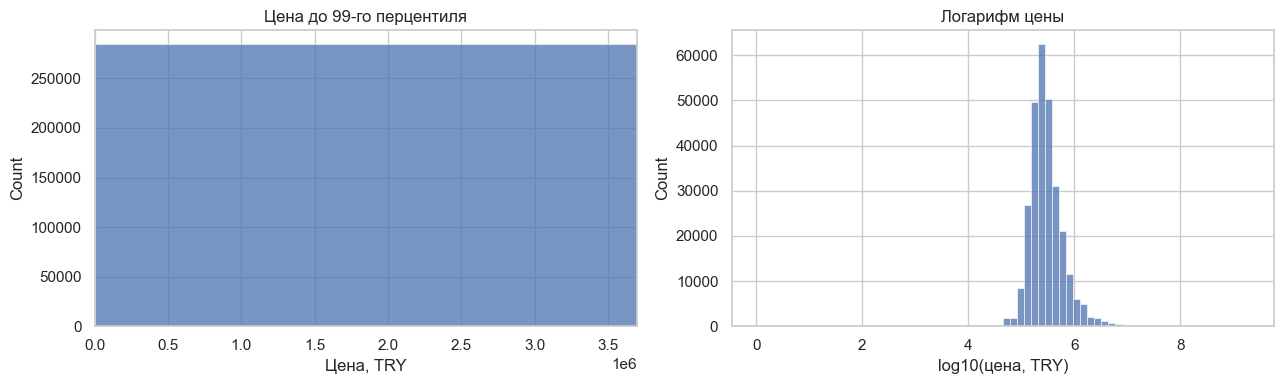

In [6]:
# Логарифм цены позволяет увидеть основную массу объявлений при длинном правом хвосте.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(sale.price, bins=80, ax=ax[0]); ax[0].set(xlim=(0, sale.price.quantile(.99)), xlabel="Цена, TRY", title="Цена до 99-го перцентиля")
sns.histplot(sale.log_price, bins=70, ax=ax[1]); ax[1].set(xlabel="log10(цена, TRY)", title="Логарифм цены")
plt.tight_layout(); plt.show()

**Вывод 1.2.** В сегменте продажи за TRY 284 468 объявлений с положительной ценой. Медиана цены — 270 000 TRY; среднее заметно выше из-за правого хвоста и экстремальных значений. Типичная записанная площадь около 110–115 м², но значительная её часть отсутствует. У `building_age` есть интервальные значения, поэтому вычислять точный год постройки нельзя.

## 1.3. Визуальный анализ

Ниже пять типов графиков: гистограммы, scatter, boxplot, тепловая карта и столбчатые диаграммы. Для читаемости некоторые оси ограничены 99-м перцентилем, а scatter строится по фиксированной случайной подвыборке. Эти ограничения не удаляют строки из исходных данных.

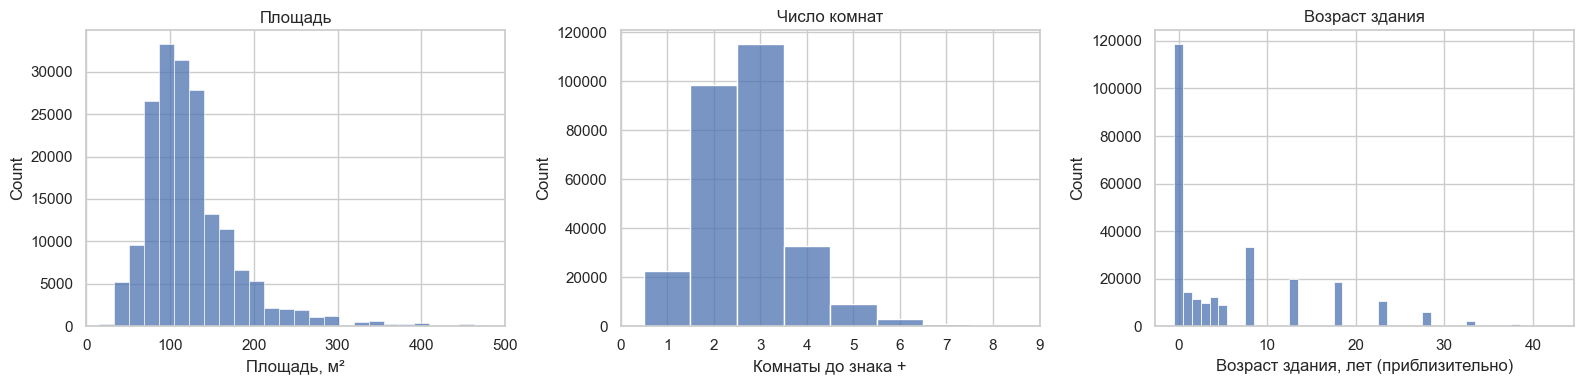

In [7]:
# Распределения площади, комнат и приблизительного возраста здания.
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(sale.size_valid.dropna(), bins=55, ax=ax[0]); ax[0].set(xlim=(0,500), xlabel="Площадь, м²", title="Площадь")
sns.histplot(sale.rooms.dropna(), discrete=True, ax=ax[1]); ax[1].set(xlim=(0,9), xlabel="Комнаты до знака +", title="Число комнат")
sns.histplot(sale.age_approx.dropna(), discrete=True, ax=ax[2]); ax[2].set(xlabel="Возраст здания, лет (приблизительно)", title="Возраст здания")
plt.tight_layout(); plt.show()

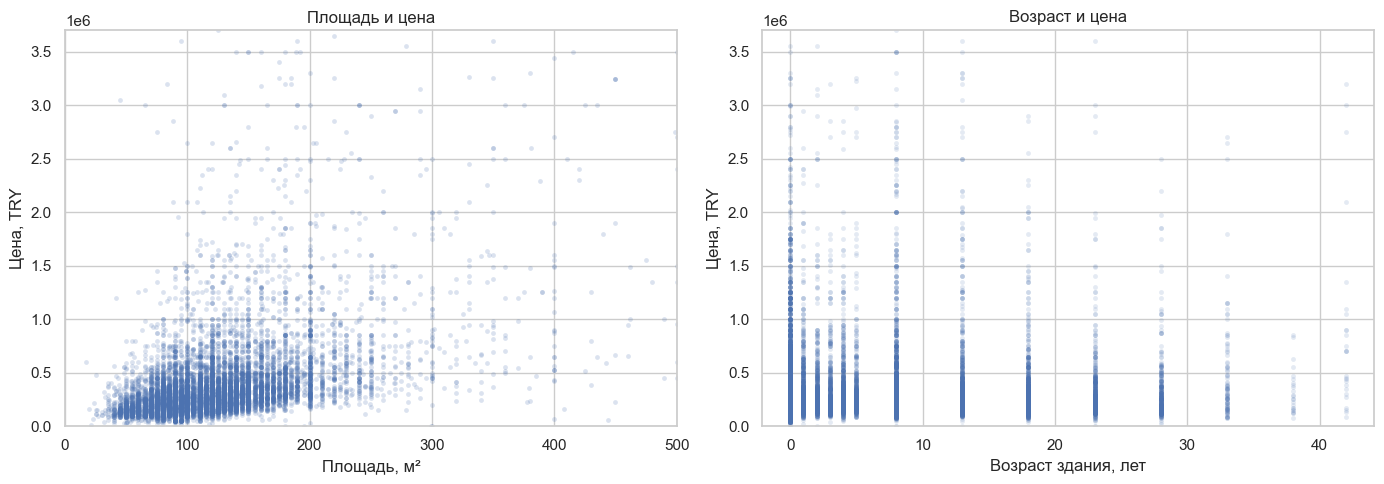

In [8]:
# Признак—цена: площадь и приблизительный возраст здания.
sample = sale.loc[sale.size_valid.notna()].sample(n=min(12000, sale.size_valid.notna().sum()), random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=sample, x="size_valid", y="price", alpha=.2, s=12, linewidth=0, ax=ax[0])
ax[0].set(xlim=(0,500), ylim=(0,sale.price.quantile(.99)), xlabel="Площадь, м²", ylabel="Цена, TRY", title="Площадь и цена")
age_sample = sale.loc[sale.age_approx.notna()].sample(n=min(12000, sale.age_approx.notna().sum()), random_state=RANDOM_STATE)
sns.scatterplot(data=age_sample, x="age_approx", y="price", alpha=.15, s=12, linewidth=0, ax=ax[1])
ax[1].set(ylim=(0,sale.price.quantile(.99)), xlabel="Возраст здания, лет", ylabel="Цена, TRY", title="Возраст и цена")
plt.tight_layout(); plt.show()

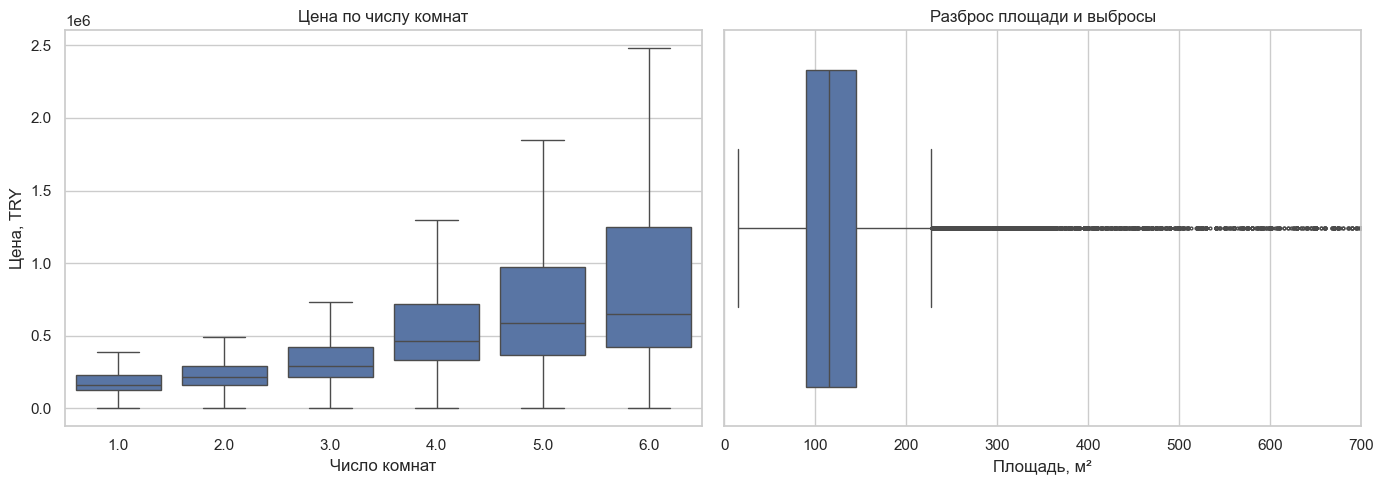

In [9]:
# Boxplot цены по комнатам и цены/площади для визуального поиска выбросов.
limited = sale.loc[sale.price.le(sale.price.quantile(.99)) & sale.rooms.between(1,6)]
fig, ax = plt.subplots(1,2,figsize=(14,5))
sns.boxplot(data=limited, x="rooms", y="price", showfliers=False, ax=ax[0])
ax[0].set(xlabel="Число комнат", ylabel="Цена, TRY", title="Цена по числу комнат")
sns.boxplot(x=sale.size_valid.dropna(), ax=ax[1], showfliers=True, flierprops={"markersize":2})
ax[1].set(xlim=(0,700), xlabel="Площадь, м²", title="Разброс площади и выбросы")
plt.tight_layout(); plt.show()

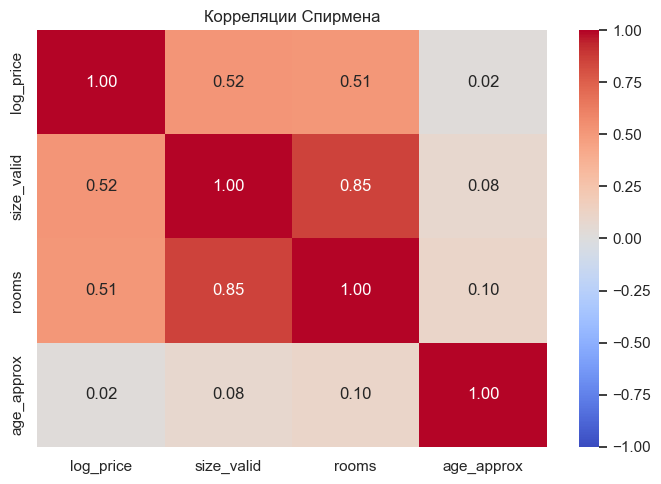

,log_price,size_valid,rooms,age_approx
log_price,1.000000,0.519294,0.512171,0.018348
size_valid,0.519294,1.000000,0.851972,0.084669
rooms,0.512171,0.851972,1.000000,0.104987
age_approx,0.018348,0.084669,0.104987,1.000000


In [10]:
# Корреляции Спирмена устойчивее Pearson к нелинейности и длинным хвостам.
corr = sale[["log_price", "size_valid", "rooms", "age_approx"]].corr(method="spearman")
plt.figure(figsize=(7,5)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Корреляции Спирмена"); plt.tight_layout(); plt.show()
display(corr)

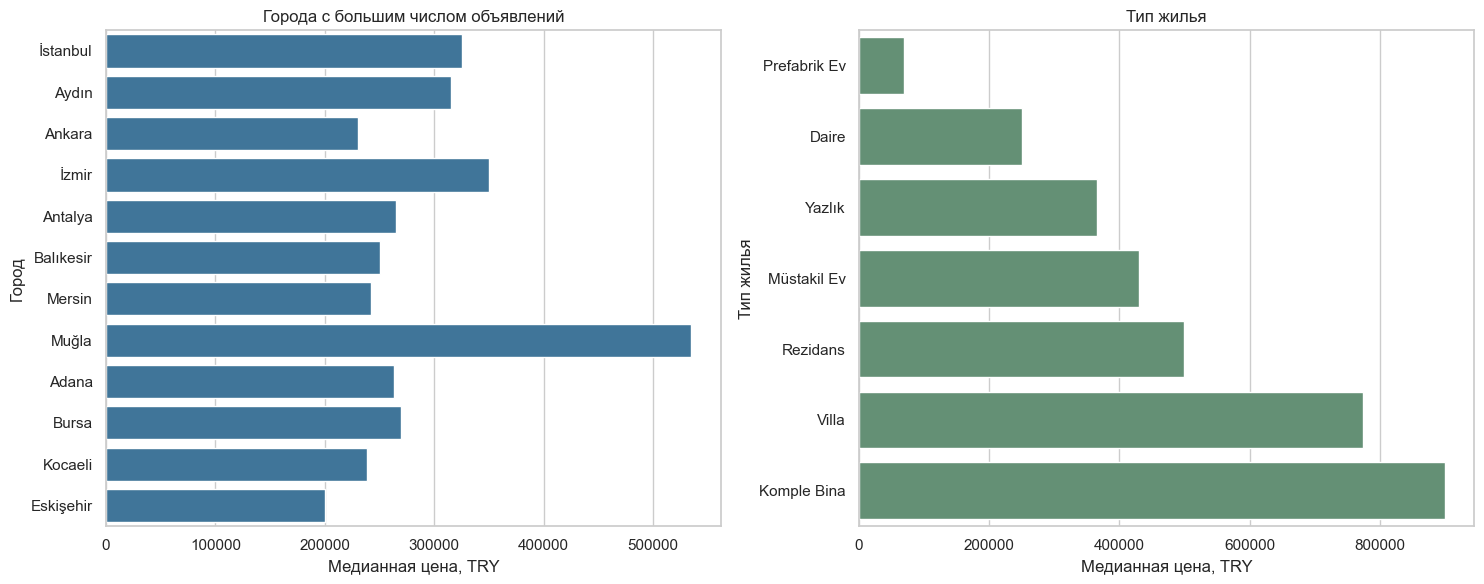

,count,median,mean
city,,,
İstanbul,70697,325000.0,8.031079e+05
Aydın,30060,315000.0,4.106377e+05
Ankara,24898,230000.0,3.179637e+05
İzmir,18886,350000.0,5.646129e+05
Antalya,17242,265000.0,4.019302e+05
Balıkesir,11684,250000.0,3.621557e+05
Mersin,8873,242000.0,5.427194e+05
Muğla,8172,535000.0,1.010546e+06
Adana,8067,263000.0,3.441515e+05


,count,median,mean
sub_type,,,
Prefabrik Ev,673,69500.0,8.518158e+04
Daire,244914,250000.0,3.547808e+05
Yazlık,5741,365000.0,4.289521e+05
Müstakil Ev,7899,430000.0,7.537826e+05
Rezidans,4249,500000.0,1.319870e+06
Villa,17906,775000.0,1.449676e+06
Komple Bina,2209,900000.0,2.672778e+06


In [11]:
# Группы не менее 500 объявлений: частоты и медианы по городам/типам.
city_stats = sale.groupby("city").price.agg(["count","median","mean"]).query("count >= 500").sort_values("count",ascending=False).head(12)
type_stats = sale.groupby("sub_type").price.agg(["count","median","mean"]).query("count >= 500").sort_values("median")
fig, ax = plt.subplots(1,2,figsize=(15,6))
sns.barplot(x=city_stats["median"],y=city_stats.index,ax=ax[0],color="#3178a8")
ax[0].set(xlabel="Медианная цена, TRY",ylabel="Город",title="Города с большим числом объявлений")
sns.barplot(x=type_stats["median"],y=type_stats.index,ax=ax[1],color="#5d9773")
ax[1].set(xlabel="Медианная цена, TRY",ylabel="Тип жилья",title="Тип жилья")
plt.tight_layout(); plt.show()
display(city_stats, type_stats)

**Вывод 1.3.** Цена растёт с площадью (ρ Спирмена около 0,52) и числом комнат (около 0,51). Площадь и комнаты связаны между собой ещё сильнее (около 0,85), что важно для линейной модели. Цены различаются по городам и типам жилья: например, медиана квартир ниже медианы вилл. Эти графики показывают ассоциации, но не доказывают самостоятельное влияние признака после учёта остальных.

## 1.4. Пропуски и аномалии

Диагностика выполняется на исходных данных. Она ничего не удаляет. Выбор способа заполнения и обработки выбросов относится к этапу предобработки после разделения на train/test.

,пропусков,доля_%
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
price_currency,715,0.18
price,715,0.18
id,0,0.00


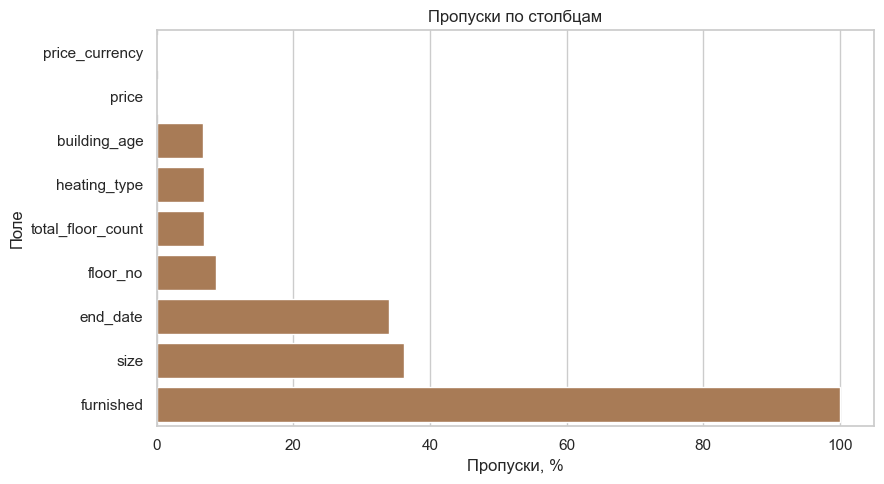

In [12]:
# Количество и доля пропусков по каждому исходному столбцу.
missing = pd.DataFrame({"пропусков": df[original_columns].isna().sum(),
                        "доля_%": df[original_columns].isna().mean().mul(100)}).sort_values("доля_%",ascending=False)
display(missing.round(2))
plt.figure(figsize=(9,5))
m = missing.loc[missing["доля_%"].gt(0)].sort_values("доля_%")
sns.barplot(x=m["доля_%"],y=m.index,color="#b67a48")
plt.xlabel("Пропуски, %"); plt.ylabel("Поле"); plt.title("Пропуски по столбцам")
plt.tight_layout(); plt.show()

In [13]:
# Проверяем точные дубликаты и логическую согласованность.
end_dates = pd.to_datetime(df.end_date,format="%m/%d/%y",errors="coerce")
diagnostics = pd.Series({
    "дубликаты_строк": int(df[original_columns].duplicated().sum()),
    "повторные_id": int(df.id.duplicated().sum()),
    "цена_пустая": int(df.price.isna().sum()),
    "цена_неположительная": int(df.price.le(0).sum()),
    "площадь_неположительная": int(df["size"].le(0).sum()),
    "площадь_вне_15_1000": int((df["size"].notna() & ~df["size"].between(15,1000)).sum()),
    "дата_начала_некорректна": int(dates.isna().sum()),
    "дата_окончания_раньше_начала": int((end_dates < dates).sum()),
    "tom_отрицательный": int(df.tom.lt(0).sum()),
    "возраст_не_распознан_среди_заполненных": int((df.building_age.notna() & pd.to_numeric(df.building_age.replace(age_map),errors="coerce").isna()).sum())
})
display(diagnostics.to_frame("количество"))
# IQR-флаги — только индикаторы экстремальности, не решение об удалении.
for col in ["price","size_valid"]:
    x = sale[col].dropna()
    q1,q3 = x.quantile([.25,.75])
    upper = q3 + 1.5*(q3-q1)
    print(f"{col}: верхняя граница IQR={upper:,.1f}; выше границы {(x>upper).sum():,} записей")

,количество
дубликаты_строк,0
повторные_id,0
цена_пустая,715
цена_неположительная,45
площадь_неположительная,0
площадь_вне_15_1000,1140
дата_начала_некорректна,0
дата_окончания_раньше_начала,0
tom_отрицательный,0
возраст_не_распознан_среди_заполненных,0


price: верхняя граница IQR=772,500.0; выше границы 25,928 записей
size_valid: верхняя граница IQR=227.5; выше границы 10,234 записей


**Вывод 1.4.** `furnished` пуст целиком, площадь отсутствует примерно у 36% строк, `end_date` — у 34%. Полных дубликатов и повторных ID нет. Есть 45 неположительных цен и 1 140 записанных площадей вне диагностического диапазона 15–1000 м². Для проверки года постройки исходного поля недостаточно: доступен возраст здания, в том числе интервальный. Наличие большого значения цены или площади само по себе не доказывает ошибку.

## 1.5. Промежуточные выводы и гипотезы

1. **Площадь повышает ожидаемую цену.** Поддержка: scatter и ρ≈0,52 с логарифмом цены. Проверить внутри городов и типов жилья.
2. **Локация объясняет часть разброса цены.** Поддержка: заметно разные медианы городов. Проверить район и микрорайон, учитывая размер групп.
3. **Тип жилья связан с ценой.** Поддержка: медиана вилл выше медианы квартир. Проверить после контроля площади и локации.
4. **Число комнат добавляет информацию, но дублирует площадь.** Поддержка: ρ с ценой ≈0,51 и ρ с площадью ≈0,85. Проверить мультиколлинеарность.
5. **Возраст здания может влиять на цену.** График возраста и тепловая карта служат первичной проверкой; интервальные значения требуют аккуратной обработки.

**Переход к этапу 2.** Не включать в признаки `id`, `end_date`, `tom` или `price / size`: последние два могут раскрывать будущее или саму цену. Сначала разделить train/test, затем обучать импутеры и кодировщики только на train. Аренду и другие валюты анализировать отдельно.